### KNN

In [2]:
'''
K- Nearest Neighbors
--------------------------
-> Does both classification and regression tasks
->Lazy Algorithm 

Formula
-----------------------
-> Euclidian Distance(root(x2-x1)2 + (y2-y1)2)'''


'\nK- Nearest Neighbors\n--------------------------\n-> Does both classification and regression tasks\n->Lazy Algorithm \n\nFormula\n-----------------------\n-> Euclidian Distance(root(x2-x1)2 + (y2-y1)2)'

In [3]:
#What to find? 
''' -> Optimal number of k (neighbor)
k = 3
'''

' -> Optimal number of k (neighbor)\nk = 3\n'

In [4]:
import pandas as pd
import numpy as np 
import matplotlib as plt
import seaborn as sns 
import matplotlib.pyplot as plt

In [5]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.metrics import classification_report, confusion_matrix

In [6]:
df = pd.read_csv('student.csv')
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,higher education,higher education,at_home,teacher,...,very good,medium,high,very low,very low,good,6,5,6,6
1,GP,F,17,U,GT3,T,primary education (4th grade),primary education (4th grade),at_home,other,...,excellent,medium,medium,very low,very low,good,4,5,5,6
2,GP,F,15,U,LE3,T,primary education (4th grade),primary education (4th grade),at_home,other,...,very good,medium,low,low,medium,good,10,7,8,10
3,GP,F,15,U,GT3,T,higher education,5th to 9th grade,health,services,...,good,low,low,very low,very low,excellent,2,15,14,15
4,GP,F,16,U,GT3,T,secondary education,secondary education,other,other,...,very good,medium,low,very low,low,excellent,4,6,10,10


In [7]:
df['G3'].sort_values(ascending= True).unique()


array([ 0,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19,
       20], dtype=int64)

In [8]:
def convertMarks(marks):
    if marks >=17 and marks <= 20: 
        return 'A'
    elif marks >= 13 and marks<17:
        return 'B'
    elif marks >= 8 and marks<13:
        return 'C'
    elif marks >= 0 and marks<8:
        return 'Fail' 
    else:
        return 'Invalid Marks to grade'
        
        
    

In [9]:
df['Grade']= df['G3'].apply(convertMarks)
df

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3,Grade
0,GP,F,18,U,GT3,A,higher education,higher education,at_home,teacher,...,medium,high,very low,very low,good,6,5,6,6,Fail
1,GP,F,17,U,GT3,T,primary education (4th grade),primary education (4th grade),at_home,other,...,medium,medium,very low,very low,good,4,5,5,6,Fail
2,GP,F,15,U,LE3,T,primary education (4th grade),primary education (4th grade),at_home,other,...,medium,low,low,medium,good,10,7,8,10,C
3,GP,F,15,U,GT3,T,higher education,5th to 9th grade,health,services,...,low,low,very low,very low,excellent,2,15,14,15,B
4,GP,F,16,U,GT3,T,secondary education,secondary education,other,other,...,medium,low,very low,low,excellent,4,6,10,10,C
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
390,MS,M,20,U,LE3,A,5th to 9th grade,5th to 9th grade,services,services,...,very high,high,high,very high,very good,11,9,9,9,C
391,MS,M,17,U,LE3,T,secondary education,primary education (4th grade),services,services,...,high,very high,medium,high,bad,3,14,16,16,B
392,MS,M,21,R,GT3,T,primary education (4th grade),primary education (4th grade),other,other,...,very high,medium,medium,medium,good,3,10,8,7,Fail
393,MS,M,18,R,LE3,T,secondary education,5th to 9th grade,services,other,...,high,very low,medium,high,excellent,0,11,12,10,C


In [10]:
df['Grade'].value_counts()

Grade
C       194
B       107
Fail     70
A        24
Name: count, dtype: int64

In [11]:
df.columns


Index(['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu',
       'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime',
       'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery',
       'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc',
       'Walc', 'health', 'absences', 'G1', 'G2', 'G3', 'Grade'],
      dtype='object')

In [12]:
df['Medu'].unique()

array(['higher education', 'primary education (4th grade)',
       'secondary education', '5th to 9th grade', 'none'], dtype=object)

In [13]:
m_f_edu={
    'none':0,
    'primary education (4th grade)':1,
    '5th to 9th grade':2,
    'secondary education':3,
    'higher education':4
}

columns =['Medu','Fedu']
for col in columns:
    df[f'{col}_id']= df[col].map(m_f_edu)
    

In [14]:
df['traveltime'].unique()

array(['15 to 30 min.', '<15 min.', '30 min. to 1 hour', '>1 hour'],
      dtype=object)

In [15]:
tt_id={
    '<15 min.':0,
    '15 to 30 min.' : 1,
    '30 min. to 1 hour':2,
    '>1 hour':3

}
df['traveltime_id']=df['traveltime'].map(tt_id)
    
    
    

In [16]:
def labelEncoderData(dataframe, col_name, *args):
    encoding_val = {}

    for idx, val in enumerate(args):
        encoding_val[val] = idx

    dataframe[f'{col_name}_id'] = dataframe[col_name].map(encoding_val)

    return dataframe

In [17]:
df['studytime'].unique()

array(['2 to 5 hours', '5 to 10 hours', '<2 hours', '>10 hours'],
      dtype=object)

In [18]:
labelEncoderData(df,'studytime','<2hours','2 to 5 hours','>10 hours')

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,health,absences,G1,G2,G3,Grade,Medu_id,Fedu_id,traveltime_id,studytime_id
0,GP,F,18,U,GT3,A,higher education,higher education,at_home,teacher,...,good,6,5,6,6,Fail,4,4,1,1.0
1,GP,F,17,U,GT3,T,primary education (4th grade),primary education (4th grade),at_home,other,...,good,4,5,5,6,Fail,1,1,0,1.0
2,GP,F,15,U,LE3,T,primary education (4th grade),primary education (4th grade),at_home,other,...,good,10,7,8,10,C,1,1,0,1.0
3,GP,F,15,U,GT3,T,higher education,5th to 9th grade,health,services,...,excellent,2,15,14,15,B,4,2,0,NaN
4,GP,F,16,U,GT3,T,secondary education,secondary education,other,other,...,excellent,4,6,10,10,C,3,3,0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
390,MS,M,20,U,LE3,A,5th to 9th grade,5th to 9th grade,services,services,...,very good,11,9,9,9,C,2,2,0,1.0
391,MS,M,17,U,LE3,T,secondary education,primary education (4th grade),services,services,...,bad,3,14,16,16,B,3,1,1,NaN
392,MS,M,21,R,GT3,T,primary education (4th grade),primary education (4th grade),other,other,...,good,3,10,8,7,Fail,1,1,0,NaN
393,MS,M,18,R,LE3,T,secondary education,5th to 9th grade,services,other,...,excellent,0,11,12,10,C,3,2,2,NaN


In [19]:
df[['studytime','studytime_id']]

,studytime,studytime_id
0,2 to 5 hours,1.0
1,2 to 5 hours,1.0
2,2 to 5 hours,1.0
3,5 to 10 hours,NaN
4,2 to 5 hours,1.0
...,...,...
390,2 to 5 hours,1.0
391,<2 hours,NaN
392,<2 hours,NaN
393,<2 hours,NaN


In [20]:
df['schoolsup'].unique()

array(['yes', 'no'], dtype=object)

In [21]:
labelEncoderData(df, 'schoolsup', 'no', 'yes')

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,absences,G1,G2,G3,Grade,Medu_id,Fedu_id,traveltime_id,studytime_id,schoolsup_id
0,GP,F,18,U,GT3,A,higher education,higher education,at_home,teacher,...,6,5,6,6,Fail,4,4,1,1.0,1
1,GP,F,17,U,GT3,T,primary education (4th grade),primary education (4th grade),at_home,other,...,4,5,5,6,Fail,1,1,0,1.0,0
2,GP,F,15,U,LE3,T,primary education (4th grade),primary education (4th grade),at_home,other,...,10,7,8,10,C,1,1,0,1.0,1
3,GP,F,15,U,GT3,T,higher education,5th to 9th grade,health,services,...,2,15,14,15,B,4,2,0,NaN,0
4,GP,F,16,U,GT3,T,secondary education,secondary education,other,other,...,4,6,10,10,C,3,3,0,1.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
390,MS,M,20,U,LE3,A,5th to 9th grade,5th to 9th grade,services,services,...,11,9,9,9,C,2,2,0,1.0,0
391,MS,M,17,U,LE3,T,secondary education,primary education (4th grade),services,services,...,3,14,16,16,B,3,1,1,NaN,0
392,MS,M,21,R,GT3,T,primary education (4th grade),primary education (4th grade),other,other,...,3,10,8,7,Fail,1,1,0,NaN,0
393,MS,M,18,R,LE3,T,secondary education,5th to 9th grade,services,other,...,0,11,12,10,C,3,2,2,NaN,0


In [22]:
labelEncoderData(df,'famsup','no','yes')

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,G1,G2,G3,Grade,Medu_id,Fedu_id,traveltime_id,studytime_id,schoolsup_id,famsup_id
0,GP,F,18,U,GT3,A,higher education,higher education,at_home,teacher,...,5,6,6,Fail,4,4,1,1.0,1,0
1,GP,F,17,U,GT3,T,primary education (4th grade),primary education (4th grade),at_home,other,...,5,5,6,Fail,1,1,0,1.0,0,1
2,GP,F,15,U,LE3,T,primary education (4th grade),primary education (4th grade),at_home,other,...,7,8,10,C,1,1,0,1.0,1,0
3,GP,F,15,U,GT3,T,higher education,5th to 9th grade,health,services,...,15,14,15,B,4,2,0,NaN,0,1
4,GP,F,16,U,GT3,T,secondary education,secondary education,other,other,...,6,10,10,C,3,3,0,1.0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
390,MS,M,20,U,LE3,A,5th to 9th grade,5th to 9th grade,services,services,...,9,9,9,C,2,2,0,1.0,0,1
391,MS,M,17,U,LE3,T,secondary education,primary education (4th grade),services,services,...,14,16,16,B,3,1,1,NaN,0,0
392,MS,M,21,R,GT3,T,primary education (4th grade),primary education (4th grade),other,other,...,10,8,7,Fail,1,1,0,NaN,0,0
393,MS,M,18,R,LE3,T,secondary education,5th to 9th grade,services,other,...,11,12,10,C,3,2,2,NaN,0,0


In [23]:
labelEncoderData(df,'internet','no','yes')

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,G2,G3,Grade,Medu_id,Fedu_id,traveltime_id,studytime_id,schoolsup_id,famsup_id,internet_id
0,GP,F,18,U,GT3,A,higher education,higher education,at_home,teacher,...,6,6,Fail,4,4,1,1.0,1,0,0
1,GP,F,17,U,GT3,T,primary education (4th grade),primary education (4th grade),at_home,other,...,5,6,Fail,1,1,0,1.0,0,1,1
2,GP,F,15,U,LE3,T,primary education (4th grade),primary education (4th grade),at_home,other,...,8,10,C,1,1,0,1.0,1,0,1
3,GP,F,15,U,GT3,T,higher education,5th to 9th grade,health,services,...,14,15,B,4,2,0,NaN,0,1,1
4,GP,F,16,U,GT3,T,secondary education,secondary education,other,other,...,10,10,C,3,3,0,1.0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
390,MS,M,20,U,LE3,A,5th to 9th grade,5th to 9th grade,services,services,...,9,9,C,2,2,0,1.0,0,1,0
391,MS,M,17,U,LE3,T,secondary education,primary education (4th grade),services,services,...,16,16,B,3,1,1,NaN,0,0,1
392,MS,M,21,R,GT3,T,primary education (4th grade),primary education (4th grade),other,other,...,8,7,Fail,1,1,0,NaN,0,0,0
393,MS,M,18,R,LE3,T,secondary education,5th to 9th grade,services,other,...,12,10,C,3,2,2,NaN,0,0,1


In [24]:
labelEncoderData(df,'freetime','very low','low','medium','high','very high ')

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,G3,Grade,Medu_id,Fedu_id,traveltime_id,studytime_id,schoolsup_id,famsup_id,internet_id,freetime_id
0,GP,F,18,U,GT3,A,higher education,higher education,at_home,teacher,...,6,Fail,4,4,1,1.0,1,0,0,2.0
1,GP,F,17,U,GT3,T,primary education (4th grade),primary education (4th grade),at_home,other,...,6,Fail,1,1,0,1.0,0,1,1,2.0
2,GP,F,15,U,LE3,T,primary education (4th grade),primary education (4th grade),at_home,other,...,10,C,1,1,0,1.0,1,0,1,2.0
3,GP,F,15,U,GT3,T,higher education,5th to 9th grade,health,services,...,15,B,4,2,0,NaN,0,1,1,1.0
4,GP,F,16,U,GT3,T,secondary education,secondary education,other,other,...,10,C,3,3,0,1.0,0,1,0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
390,MS,M,20,U,LE3,A,5th to 9th grade,5th to 9th grade,services,services,...,9,C,2,2,0,1.0,0,1,0,NaN
391,MS,M,17,U,LE3,T,secondary education,primary education (4th grade),services,services,...,16,B,3,1,1,NaN,0,0,1,3.0
392,MS,M,21,R,GT3,T,primary education (4th grade),primary education (4th grade),other,other,...,7,Fail,1,1,0,NaN,0,0,0,NaN
393,MS,M,18,R,LE3,T,secondary education,5th to 9th grade,services,other,...,10,C,3,2,2,NaN,0,0,1,3.0


In [25]:
labelEncoderData(df,'goout','very low','low','medium','high','very high ')

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,Grade,Medu_id,Fedu_id,traveltime_id,studytime_id,schoolsup_id,famsup_id,internet_id,freetime_id,goout_id
0,GP,F,18,U,GT3,A,higher education,higher education,at_home,teacher,...,Fail,4,4,1,1.0,1,0,0,2.0,3.0
1,GP,F,17,U,GT3,T,primary education (4th grade),primary education (4th grade),at_home,other,...,Fail,1,1,0,1.0,0,1,1,2.0,2.0
2,GP,F,15,U,LE3,T,primary education (4th grade),primary education (4th grade),at_home,other,...,C,1,1,0,1.0,1,0,1,2.0,1.0
3,GP,F,15,U,GT3,T,higher education,5th to 9th grade,health,services,...,B,4,2,0,NaN,0,1,1,1.0,1.0
4,GP,F,16,U,GT3,T,secondary education,secondary education,other,other,...,C,3,3,0,1.0,0,1,0,2.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
390,MS,M,20,U,LE3,A,5th to 9th grade,5th to 9th grade,services,services,...,C,2,2,0,1.0,0,1,0,NaN,3.0
391,MS,M,17,U,LE3,T,secondary education,primary education (4th grade),services,services,...,B,3,1,1,NaN,0,0,1,3.0,NaN
392,MS,M,21,R,GT3,T,primary education (4th grade),primary education (4th grade),other,other,...,Fail,1,1,0,NaN,0,0,0,NaN,2.0
393,MS,M,18,R,LE3,T,secondary education,5th to 9th grade,services,other,...,C,3,2,2,NaN,0,0,1,3.0,0.0


In [26]:
labelEncoderData(df,'Dalc','very low','low','medium','high','very high ')

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,Medu_id,Fedu_id,traveltime_id,studytime_id,schoolsup_id,famsup_id,internet_id,freetime_id,goout_id,Dalc_id
0,GP,F,18,U,GT3,A,higher education,higher education,at_home,teacher,...,4,4,1,1.0,1,0,0,2.0,3.0,0.0
1,GP,F,17,U,GT3,T,primary education (4th grade),primary education (4th grade),at_home,other,...,1,1,0,1.0,0,1,1,2.0,2.0,0.0
2,GP,F,15,U,LE3,T,primary education (4th grade),primary education (4th grade),at_home,other,...,1,1,0,1.0,1,0,1,2.0,1.0,1.0
3,GP,F,15,U,GT3,T,higher education,5th to 9th grade,health,services,...,4,2,0,NaN,0,1,1,1.0,1.0,0.0
4,GP,F,16,U,GT3,T,secondary education,secondary education,other,other,...,3,3,0,1.0,0,1,0,2.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
390,MS,M,20,U,LE3,A,5th to 9th grade,5th to 9th grade,services,services,...,2,2,0,1.0,0,1,0,NaN,3.0,3.0
391,MS,M,17,U,LE3,T,secondary education,primary education (4th grade),services,services,...,3,1,1,NaN,0,0,1,3.0,NaN,2.0
392,MS,M,21,R,GT3,T,primary education (4th grade),primary education (4th grade),other,other,...,1,1,0,NaN,0,0,0,NaN,2.0,2.0
393,MS,M,18,R,LE3,T,secondary education,5th to 9th grade,services,other,...,3,2,2,NaN,0,0,1,3.0,0.0,2.0


In [27]:
labelEncoderData(df,'Walc','very low','low','medium','high','very high ')

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,Fedu_id,traveltime_id,studytime_id,schoolsup_id,famsup_id,internet_id,freetime_id,goout_id,Dalc_id,Walc_id
0,GP,F,18,U,GT3,A,higher education,higher education,at_home,teacher,...,4,1,1.0,1,0,0,2.0,3.0,0.0,0.0
1,GP,F,17,U,GT3,T,primary education (4th grade),primary education (4th grade),at_home,other,...,1,0,1.0,0,1,1,2.0,2.0,0.0,0.0
2,GP,F,15,U,LE3,T,primary education (4th grade),primary education (4th grade),at_home,other,...,1,0,1.0,1,0,1,2.0,1.0,1.0,2.0
3,GP,F,15,U,GT3,T,higher education,5th to 9th grade,health,services,...,2,0,NaN,0,1,1,1.0,1.0,0.0,0.0
4,GP,F,16,U,GT3,T,secondary education,secondary education,other,other,...,3,0,1.0,0,1,0,2.0,1.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
390,MS,M,20,U,LE3,A,5th to 9th grade,5th to 9th grade,services,services,...,2,0,1.0,0,1,0,NaN,3.0,3.0,NaN
391,MS,M,17,U,LE3,T,secondary education,primary education (4th grade),services,services,...,1,1,NaN,0,0,1,3.0,NaN,2.0,3.0
392,MS,M,21,R,GT3,T,primary education (4th grade),primary education (4th grade),other,other,...,1,0,NaN,0,0,0,NaN,2.0,2.0,2.0
393,MS,M,18,R,LE3,T,secondary education,5th to 9th grade,services,other,...,2,2,NaN,0,0,1,3.0,0.0,2.0,3.0


In [28]:
labelEncoderData(df,'health','very bad','bad','good','very good','excellent')

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,traveltime_id,studytime_id,schoolsup_id,famsup_id,internet_id,freetime_id,goout_id,Dalc_id,Walc_id,health_id
0,GP,F,18,U,GT3,A,higher education,higher education,at_home,teacher,...,1,1.0,1,0,0,2.0,3.0,0.0,0.0,2
1,GP,F,17,U,GT3,T,primary education (4th grade),primary education (4th grade),at_home,other,...,0,1.0,0,1,1,2.0,2.0,0.0,0.0,2
2,GP,F,15,U,LE3,T,primary education (4th grade),primary education (4th grade),at_home,other,...,0,1.0,1,0,1,2.0,1.0,1.0,2.0,2
3,GP,F,15,U,GT3,T,higher education,5th to 9th grade,health,services,...,0,NaN,0,1,1,1.0,1.0,0.0,0.0,4
4,GP,F,16,U,GT3,T,secondary education,secondary education,other,other,...,0,1.0,0,1,0,2.0,1.0,0.0,1.0,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
390,MS,M,20,U,LE3,A,5th to 9th grade,5th to 9th grade,services,services,...,0,1.0,0,1,0,NaN,3.0,3.0,NaN,3
391,MS,M,17,U,LE3,T,secondary education,primary education (4th grade),services,services,...,1,NaN,0,0,1,3.0,NaN,2.0,3.0,1
392,MS,M,21,R,GT3,T,primary education (4th grade),primary education (4th grade),other,other,...,0,NaN,0,0,0,NaN,2.0,2.0,2.0,2
393,MS,M,18,R,LE3,T,secondary education,5th to 9th grade,services,other,...,2,NaN,0,0,1,3.0,0.0,2.0,3.0,4


In [29]:
labelEncoderData(df,'Grade','Fail', 'C','B','A')

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,studytime_id,schoolsup_id,famsup_id,internet_id,freetime_id,goout_id,Dalc_id,Walc_id,health_id,Grade_id
0,GP,F,18,U,GT3,A,higher education,higher education,at_home,teacher,...,1.0,1,0,0,2.0,3.0,0.0,0.0,2,0
1,GP,F,17,U,GT3,T,primary education (4th grade),primary education (4th grade),at_home,other,...,1.0,0,1,1,2.0,2.0,0.0,0.0,2,0
2,GP,F,15,U,LE3,T,primary education (4th grade),primary education (4th grade),at_home,other,...,1.0,1,0,1,2.0,1.0,1.0,2.0,2,1
3,GP,F,15,U,GT3,T,higher education,5th to 9th grade,health,services,...,NaN,0,1,1,1.0,1.0,0.0,0.0,4,2
4,GP,F,16,U,GT3,T,secondary education,secondary education,other,other,...,1.0,0,1,0,2.0,1.0,0.0,1.0,4,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
390,MS,M,20,U,LE3,A,5th to 9th grade,5th to 9th grade,services,services,...,1.0,0,1,0,NaN,3.0,3.0,NaN,3,1
391,MS,M,17,U,LE3,T,secondary education,primary education (4th grade),services,services,...,NaN,0,0,1,3.0,NaN,2.0,3.0,1,2
392,MS,M,21,R,GT3,T,primary education (4th grade),primary education (4th grade),other,other,...,NaN,0,0,0,NaN,2.0,2.0,2.0,2,0
393,MS,M,18,R,LE3,T,secondary education,5th to 9th grade,services,other,...,NaN,0,0,1,3.0,0.0,2.0,3.0,4,1


In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 47 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   school         395 non-null    object 
 1   sex            395 non-null    object 
 2   age            395 non-null    int64  
 3   address        395 non-null    object 
 4   famsize        395 non-null    object 
 5   Pstatus        395 non-null    object 
 6   Medu           395 non-null    object 
 7   Fedu           395 non-null    object 
 8   Mjob           395 non-null    object 
 9   Fjob           395 non-null    object 
 10  reason         395 non-null    object 
 11  guardian       395 non-null    object 
 12  traveltime     395 non-null    object 
 13  studytime      395 non-null    object 
 14  failures       395 non-null    int64  
 15  schoolsup      395 non-null    object 
 16  famsup         395 non-null    object 
 17  paid           395 non-null    object 
 18  activities

In [31]:
df_sample= df.select_dtypes('int64')
df_sample = df_sample.drop(columns=['age','G3'])

In [32]:
df_sample.columns

Index(['failures', 'absences', 'G1', 'G2', 'Medu_id', 'Fedu_id',
       'traveltime_id', 'schoolsup_id', 'famsup_id', 'internet_id',
       'health_id', 'Grade_id'],
      dtype='object')

In [70]:
features=[ 'Medu_id', 'Fedu_id',
       'traveltime_id', 'famsup_id', 'schoolsup_id', 'internet_id',
       'health_id','failures', 'absences', 'G1', 'G2']
target = 'Grade_id'

In [72]:
X= df_sample[features]
Y= df_sample[target]

In [74]:
X_train, X_test,Y_train, Y_test = train_test_split(
    X,Y, test_size=0.2, random_state= 42, stratify = Y
    

)

In [76]:
scaler = StandardScaler()


In [78]:
X_train_scale = scaler.fit_transform(X_train)
X_test_scale = scaler.transform(X_test)

In [80]:
smote = SMOTE(random_state=42)
X_train_balanced , Y_train_balanced = smote.fit_resample(X_train, Y_train)

In [82]:
X_train_scale = scaler.fit_transform(X_train_balanced)
X_test_scale = scaler.transform(X_test)

In [85]:

X_train_scale

array([[ 1.22446042,  1.60595146, -0.50227525, ...,  0.16004446,
         1.50347897,  1.52683589],
       [ 0.26349148,  0.57946702, -0.50227525, ...,  0.73863085,
        -0.42895319, -0.10424445],
       [-0.69747745, -0.44701742, -0.50227525, ..., -0.12924873,
        -0.42895319, -0.30812949],
       ...,
       [-0.69747745, -1.47350186,  1.26710347, ...,  0.01539786,
         1.50347897,  1.32295085],
       [ 0.26349148, -0.44701742, -0.50227525, ..., -0.70783513,
         1.02037093,  1.11906581],
       [ 0.26349148, -0.44701742, -0.50227525, ..., -0.56318853,
         1.02037093,  1.11906581]])

### Elbow Method

NameError: name 'knn' is not defined

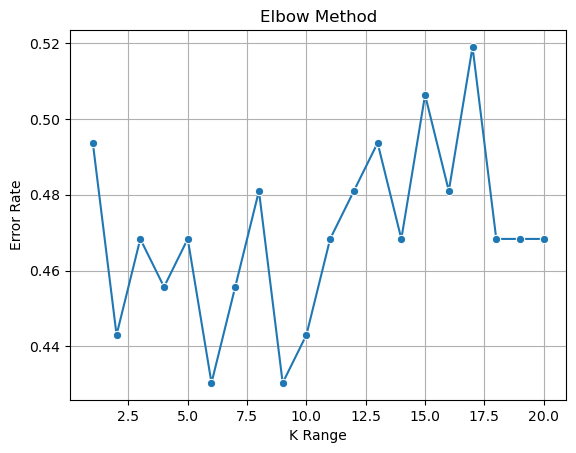

In [145]:
from sklearn.neighbors import KNeighborsClassifier
import numpy as np

k_range = range(1, 21)
error_rate = []

for k in k_range:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train_scale, Y_train_balanced)

    y_pred = model.predict(X_test_scale)

    error = np.mean(y_pred != Y_test)
    error_rate.append(error)

sns.lineplot(x=list(k_range), y=error_rate, marker='o')
plt.grid()
plt.xlabel('K Range')
plt.ylabel('Error Rate')
plt.title('Elbow Method')
plt.show()

In [147]:
k = 5
model = KNeighborsClassifier(n_neighbors=k)
model.fit (X_train_scale, Y_train_balanced)
Y_pred = model.predict(X_test_scale)
   

In [149]:
cr= classification_report(Y_test,Y_pred)
cm = confusion_matrix(Y_test,Y_pred)

In [151]:
print(cr)

              precision    recall  f1-score   support

           0       0.52      0.79      0.63        14
           1       0.65      0.51      0.57        39
           2       0.42      0.48      0.44        21
           3       0.33      0.20      0.25         5

    accuracy                           0.53        79
   macro avg       0.48      0.49      0.47        79
weighted avg       0.54      0.53      0.53        79



In [153]:
print(cm)

[[11  3  0  0]
 [ 9 20 10  0]
 [ 1  8 10  2]
 [ 0  0  4  1]]


### OverSampling

<Axes: >

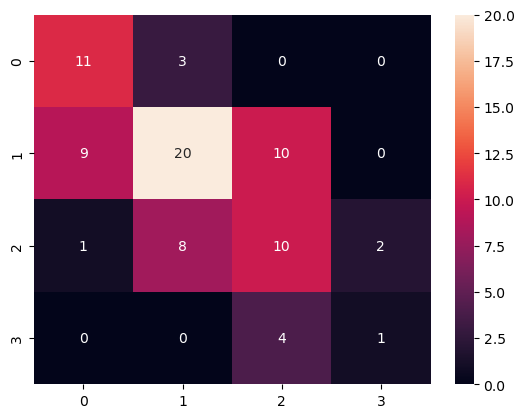

In [156]:
sns.heatmap(cm,annot = True)


### SVM Implementatation

In [159]:
from sklearn.svm import SVC 

In [161]:
svm_model= SVC( kernel ='linear', gamma =0.1, C=10)

In [163]:
svm_model.fit(X_train_scale,Y_train_balanced)

SVC(C=10, gamma=0.1, kernel='linear')

In [165]:
svm_pred = svm_model.predict(X_test_scale)

In [167]:
svm_cr = classification_report(Y_test, svm_pred)
svm_cm = confusion_matrix(Y_test, svm_pred)

In [169]:
print(svm_cr)

              precision    recall  f1-score   support

           0       0.69      0.64      0.67        14
           1       0.82      0.82      0.82        39
           2       0.86      0.86      0.86        21
           3       0.83      1.00      0.91         5

    accuracy                           0.81        79
   macro avg       0.80      0.83      0.81        79
weighted avg       0.81      0.81      0.81        79



In [171]:
print(svm_cm)

[[ 9  5  0  0]
 [ 4 32  3  0]
 [ 0  2 18  1]
 [ 0  0  0  5]]


In [174]:
df.columns

Index(['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu',
       'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime',
       'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery',
       'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc',
       'Walc', 'health', 'absences', 'G1', 'G2', 'G3', 'Grade', 'Medu_id',
       'Fedu_id', 'traveltime_id', 'studytime_id', 'schoolsup_id', 'famsup_id',
       'internet_id', 'freetime_id', 'goout_id', 'Dalc_id', 'Walc_id',
       'health_id', 'Grade_id'],
      dtype='object')